In [6]:
import os

folder_path = r"C:\Users\halee\OneDrive\Documents"

# Check if the folder itself exists
if os.path.exists(folder_path):
    print("--- Files found in your Documents folder ---")
    files = os.listdir(folder_path)
    found_any = False
    for f in files:
        if "healthcare" in f.lower():
            print(f"-> Found file: '{f}'")
            found_any = True
    if not found_any:
        print("No files containing the word 'healthcare' were found in this folder.")
else:
    print("The Documents folder path could not be found.")

--- Files found in your Documents folder ---
-> Found file: 'cleaned_healthcare_dataset.csv'
-> Found file: 'HealthcareDB_Assignment.zip'
-> Found file: 'healthcare_dataset.xlsx'


In [11]:
df = pd.read_excel(r"C:\Users\halee\OneDrive\Documents\healthcare_dataset.xlsx")

In [13]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.28131,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.32729,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.09608,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.78241,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.31781,458,Urgent,2022-10-09,Penicillin,Abnormal


In [14]:
# Check how many rows we have before dropping duplicates
print("Rows before:", len(df))

# Drop exact duplicate rows
df = df.drop_duplicates()

print("Rows after dropping duplicates:", len(df))

Rows before: 55500
Rows after dropping duplicates: 54966


In [15]:
# Fix erratic capitalization
df['Name'] = df['Name'].str.strip().str.title()
df['Doctor'] = df['Doctor'].str.strip().str.title()

# Clean up hospital names by stripping extra spaces and trailing commas
df['Hospital'] = df['Hospital'].str.strip().str.rstrip(',')

# View a few rows to verify the text looks neat
df[['Name', 'Doctor', 'Hospital']].head()

,Name,Doctor,Hospital
0,Bobby Jackson,Matthew Smith,Sons and Miller
1,Leslie Terry,Samantha Davies,Kim Inc
2,Danny Smith,Tiffany Mitchell,Cook PLC
3,Andrew Watts,Kevin Wells,Hernandez Rogers and Vang
4,Adrienne Bell,Kathleen Hanna,White-White


In [16]:
# Convert to official date format
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])

# Print data types to verify they changed to datetime64
print(df[['Date of Admission', 'Discharge Date']].dtypes)

Date of Admission    datetime64[ns]
Discharge Date       datetime64[ns]
dtype: object


In [17]:
# Convert any negative bills to positive absolute values
df['Billing Amount'] = df['Billing Amount'].abs()

# Round to standard 2 decimal places
df['Billing Amount'] = df['Billing Amount'].round(2)

# Verify the changes
df['Billing Amount'].describe()

count    54966.000000
mean     25546.244261
std      14204.924895
min          9.240000
25%      13243.722500
50%      25542.750000
75%      37819.857500
max      52764.280000
Name: Billing Amount, dtype: float64

In [18]:
import pandas as pd

# 1. Load the original raw Excel file
path = r"C:\Users\halee\OneDrive\Documents\healthcare_dataset.xlsx"
df = pd.read_excel(path)

print(f"Initial dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("-" * 50)

# 2. Remove all Null / Missing Values
# (Checks for any empty cells and drops them to keep the data complete)
initial_null_count = df.isnull().sum().sum()
df = df.dropna()
print(f"Dropped rows with null values. Total null cells found: {initial_null_count}")

# 3. Remove Duplicate Rows
# (Eliminates identical rows that skew metrics)
initial_rows = len(df)
df = df.drop_duplicates()
print(f"Removed exact duplicate rows: {initial_rows - len(df)}")

# 4. Set Proper Text Alignment & Capitalization
# (Strips hidden spaces at the beginning/end of text and fixes messy casing)
text_columns = ['Name', 'Doctor', 'Hospital', 'Insurance Provider', 'Medical Condition', 'Admission Type', 'Medication', 'Test Results']

for col in text_columns:
    if col in df.columns:
        # Strip trailing/leading whitespace
        df[col] = df[col].astype(str).str.strip()
        
# Specific casing fixes
df['Name'] = df['Name'].str.title()
df['Doctor'] = df['Doctor'].str.title()
df['Hospital'] = df['Hospital'].str.rstrip(',') # Removes accidental trailing commas

print("Text columns successfully aligned and standardized.")

# 5. Fix Numerical and Date Abnormalities
# Convert negative billing amounts to positive absolute values: |Billing Amount|
negative_bills = (df['Billing Amount'] < 0).sum()
df['Billing Amount'] = df['Billing Amount'].abs().round(2)
print(f"Corrected negative billing anomalies: {negative_bills} records fixed.")

# Convert date strings into true datetime data types
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])
print("Date objects verified and standardized.")

print("-" * 50)
print(f"Final fully cleaned dataset shape: {df.shape[0]} rows")

# 6. Save the perfectly clean data as a new file
cleaned_path = r"C:\Users\halee\OneDrive\Documents\completely_cleaned_healthcare.csv"
df.to_csv(cleaned_path, index=False)
print(f"Success! Cleaned file saved to: {cleaned_path}")

# Display a preview of your perfect data
df.head()

Initial dataset shape: 55500 rows, 15 columns
--------------------------------------------------
Dropped rows with null values. Total null cells found: 0
Removed exact duplicate rows: 534
Text columns successfully aligned and standardized.
Corrected negative billing anomalies: 106 records fixed.
Date objects verified and standardized.
--------------------------------------------------
Final fully cleaned dataset shape: 54966 rows
Success! Cleaned file saved to: C:\Users\halee\OneDrive\Documents\completely_cleaned_healthcare.csv


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.28,328,Urgent,2024-02-02,Paracetamol,Normal
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.33,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.10,205,Emergency,2022-10-07,Aspirin,Normal
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,Hernandez Rogers and Vang,Medicare,37909.78,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.32,458,Urgent,2022-10-09,Penicillin,Abnormal


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure theme configuration
sns.set_theme(style="whitegrid")

# 1. Calculate Length of Stay from our standard date dimensions
df['Length of Stay'] = (df['Discharge Date'] - df['Date of Admission']).dt.days

# Verify the metric
df[['Admission Type', 'Length of Stay', 'Billing Amount']].head()

,Admission Type,Length of Stay,Billing Amount
0,Urgent,2,18856.28
1,Emergency,6,33643.33
2,Emergency,15,27955.10
3,Elective,30,37909.78
4,Urgent,20,14238.32


--- LENGTH OF STAY BY ADMISSION TYPE ---
                     mean  median       std  count
Admission Type                                    
Emergency       15.584134    16.0  8.672724  18102
Elective        15.511178    15.0  8.645570  18473
Urgent          15.403839    15.0  8.665871  18391


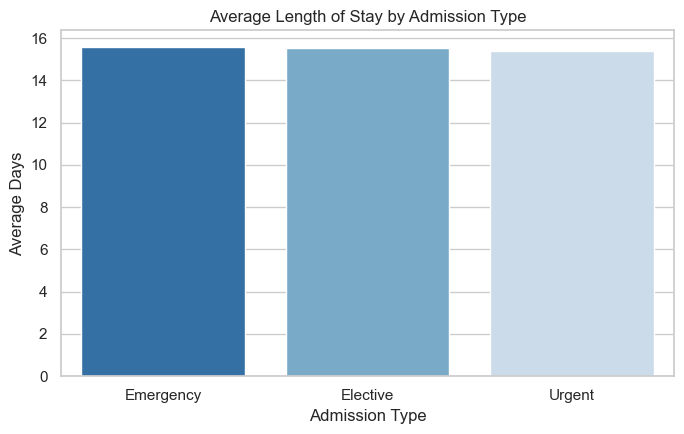

<Figure size 640x480 with 0 Axes>

In [46]:
# 1. Descriptive Statistics for Length of Stay grouped by Admission Type
los_by_admission = df.groupby('Admission Type')['Length of Stay'].agg(['mean', 'median', 'std', 'count']).sort_values(by='mean', ascending=False)
print("--- LENGTH OF STAY BY ADMISSION TYPE ---")
print(los_by_admission)

# 2. Visualize Length of Stay vs Admission Type
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(data=los_by_admission.reset_index(), x='Admission Type', y='mean', palette='Blues_r', ax=ax, hue='Admission Type')
ax.set_title('Average Length of Stay by Admission Type')
ax.set_ylabel('Average Days')
ax.set_xlabel('Admission Type')
plt.tight_layout()
plt.show()
plt.savefig('my_plot_name.png')

--- BILLING AMOIMS BY ADMISSION TYPE ---
                        mean    median    min       max
Admission Type                                         
Elective        25614.519862  25674.74   9.24  52764.28
Urgent          25516.686811  25543.56  31.03  52373.03
Emergency       25506.598691  25413.78  23.73  52271.66


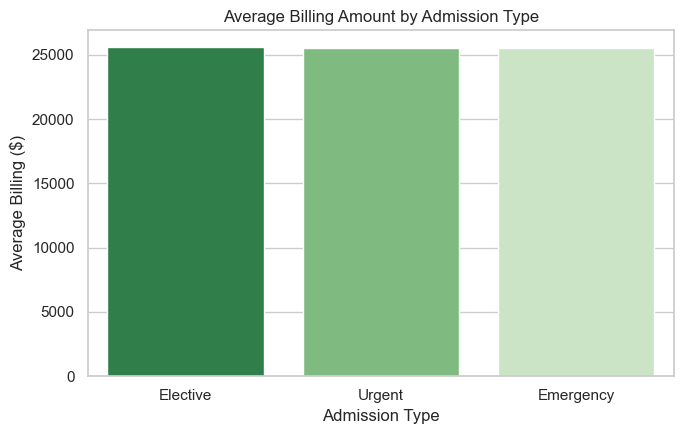

<Figure size 640x480 with 0 Axes>

In [45]:
# 1. Descriptive Statistics for Billing Amount grouped by Admission Type
billing_by_admission = df.groupby('Admission Type')['Billing Amount'].agg(['mean', 'median', 'min', 'max']).sort_values(by='mean', ascending=False)
print("--- BILLING AMOIMS BY ADMISSION TYPE ---")
print(billing_by_admission)

# 2. Visualize Billing Amount vs Admission Type
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(data=billing_by_admission.reset_index(), x='Admission Type', y='mean', palette='Greens_r', ax=ax, hue='Admission Type')
ax.set_title('Average Billing Amount by Admission Type')
ax.set_ylabel('Average Billing ($)')
ax.set_xlabel('Admission Type')
plt.tight_layout()
plt.show()
plt.savefig('my_plot_name.png')

--- PHARMACEUTICAL UTILIATION VOLUME ---
    Medication  Prescription Volume
0      Lipitor                11038
1    Ibuprofen                11023
2      Aspirin                10984
3  Paracetamol                10965
4   Penicillin                10956


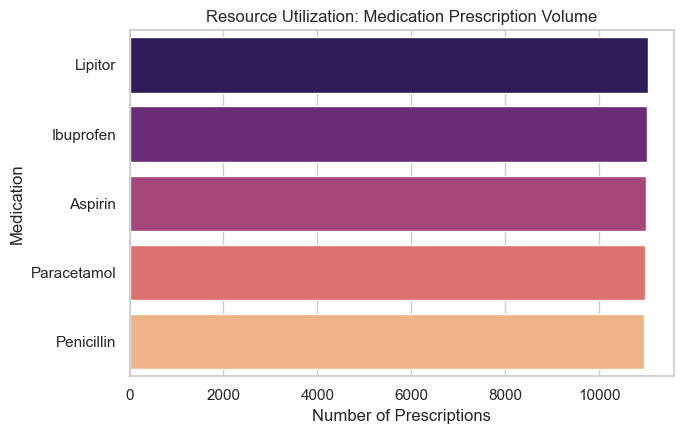

<Figure size 640x480 with 0 Axes>

In [47]:
# 1. Measure Pharmacy Resource Utilization
medication_counts = df['Medication'].value_counts().reset_index()
medication_counts.columns = ['Medication', 'Prescription Volume']

print("--- PHARMACEUTICAL UTILIATION VOLUME ---")
print(medication_counts)

# 2. Visualize Pharmacy Deployed Resources
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(data=medication_counts, x='Prescription Volume', y='Medication', palette='magma', ax=ax, hue='Medication')
ax.set_title('Resource Utilization: Medication Prescription Volume')
ax.set_xlabel('Number of Prescriptions')
ax.set_ylabel('Medication')
plt.tight_layout()
plt.show()
plt.savefig('my_plot_name.png')

--- DIAGNOSTIC OUTCOMES CROSS-TABULATION ---
Test Results    Abnormal  Inconclusive  Normal
Admission Type                                
Elective            6232          6054    6187
Emergency           6038          6020    6044
Urgent              6167          6124    6100


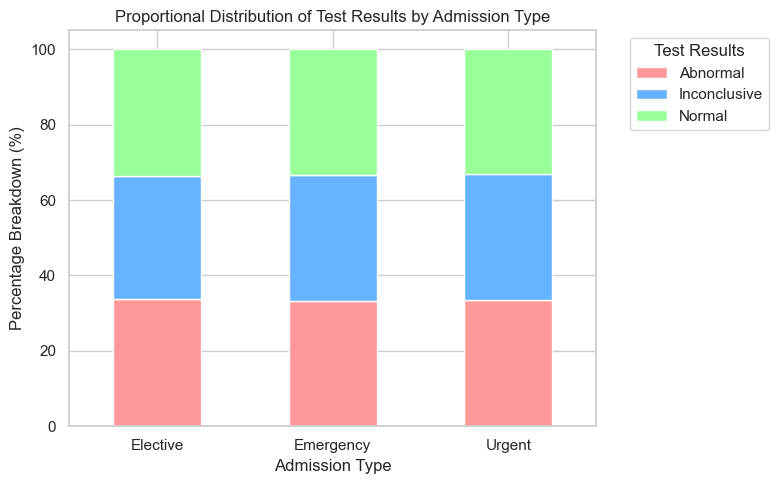

<Figure size 640x480 with 0 Axes>

In [43]:
# Cross-tabulate Admission Type with Diagnostic Test Outcomes
test_vs_admission = pd.crosstab(df['Admission Type'], df['Test Results'])
print("--- DIAGNOSTIC OUTCOMES CROSS-TABULATION ---")
print(test_vs_admission)

# Express as stacked percentage breakdown
test_admission_pct = test_vs_admission.div(test_vs_admission.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(8, 5))
test_admission_pct.plot(kind='bar', stacked=True, color=['#ff9999','#66b3ff','#99ff99'], ax=ax)
ax.set_title('Proportional Distribution of Test Results by Admission Type')
ax.set_ylabel('Percentage Breakdown (%)')
ax.set_xlabel('Admission Type')
plt.xticks(rotation=0)
plt.legend(title='Test Results', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
plt.savefig('my_plot_name.png')

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization parameters
sns.set_theme(style="whitegrid")

# Load your cleaned file
df = pd.read_csv(r"C:\Users\halee\OneDrive\Documents\completely_cleaned_healthcare.csv")

# Ensure proper date formatting
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])

--- LENGTH OF STAY ANALYTICS ---
Average Length of Stay: 15.50 days
Median Length of Stay:  15.00 days
Maximum Length of Stay: 30 days


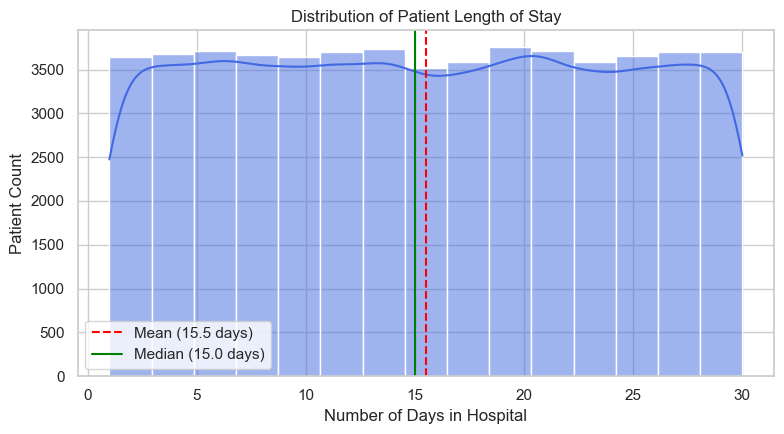

<Figure size 640x480 with 0 Axes>

In [42]:
# 1. Feature Engineering: Calculate Length of Stay
df['Length of Stay'] = (df['Discharge Date'] - df['Date of Admission']).dt.days

# 2. Compute descriptive statistics
avg_los = df['Length of Stay'].mean()
median_los = df['Length of Stay'].median()
max_los = df['Length of Stay'].max()

print("--- LENGTH OF STAY ANALYTICS ---")
print(f"Average Length of Stay: {avg_los:.2f} days")
print(f"Median Length of Stay:  {median_los:.2f} days")
print(f"Maximum Length of Stay: {max_los} days")

# 3. Visualization: Distribution Histogram
plt.figure(figsize=(8, 4.5))
sns.histplot(df['Length of Stay'], bins=15, kde=True, color='royalblue')
plt.axvline(avg_los, color='red', linestyle='--', label=f'Mean ({avg_los:.1f} days)')
plt.axvline(median_los, color='green', linestyle='-', label=f'Median ({median_los:.1f} days)')
plt.title('Distribution of Patient Length of Stay')
plt.xlabel('Number of Days in Hospital')
plt.ylabel('Patient Count')
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig('my_plot_name.png')

--- PATIENT BILLING METRICS ---
Average Patient Bill: $25,546.24
Median Patient Bill:  $25,542.75

--- AVERAGE BILLING BY DIAGNOSIS ---
Medical Condition  Billing Amount
          Obesity    25806.628370
         Diabetes    25662.147107
           Asthma    25635.639920
        Arthritis    25513.051893
     Hypertension    25504.906170
           Cancer    25154.730577


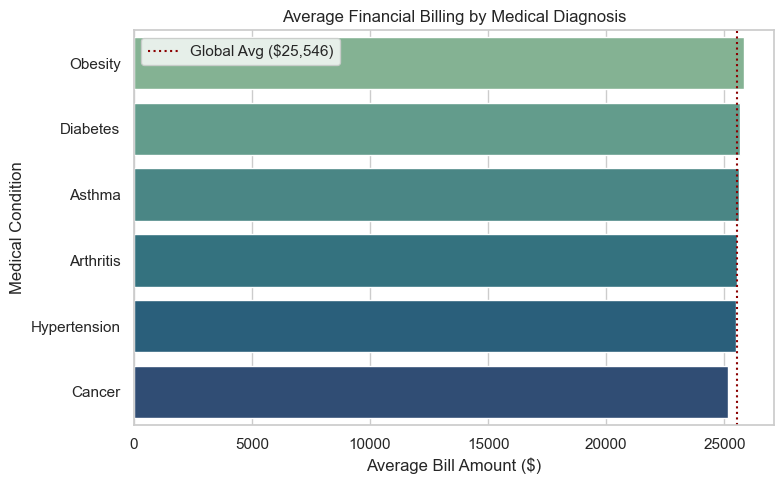

<Figure size 640x480 with 0 Axes>

In [41]:
# 1. Compute global financial metrics
avg_billing = df['Billing Amount'].mean()
median_billing = df['Billing Amount'].median()

print("--- PATIENT BILLING METRICS ---")
print(f"Average Patient Bill: ${avg_billing:,.2f}")
print(f"Median Patient Bill:  ${median_billing:,.2f}")

# 2. Break down average billing by Medical Condition
billing_by_condition = df.groupby('Medical Condition')['Billing Amount'].mean().sort_values(ascending=False).reset_index()

print("\n--- AVERAGE BILLING BY DIAGNOSIS ---")
print(billing_by_condition.to_string(index=False))

# 3. Visualization: Sorted Bar Chart
plt.figure(figsize=(8, 5))
sns.barplot(data=billing_by_condition, x='Billing Amount', y='Medical Condition', palette='crest', hue='Medical Condition')
plt.axvline(avg_billing, color='darkred', linestyle=':', label=f'Global Avg (${avg_billing:,.0f})')
plt.title('Average Financial Billing by Medical Diagnosis')
plt.xlabel('Average Bill Amount ($)')
plt.ylabel('Medical Condition')
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig('my_plot_name.png')

--- ADMISSION TYPE PROFILE DISTRIBUTION ---
Urgent: 36493 admissions (66.39%)
Non-Urgent: 18473 admissions (33.61%)


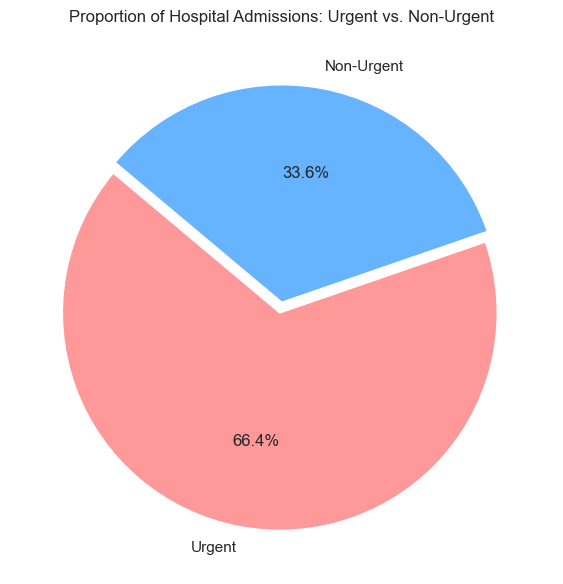

<Figure size 640x480 with 0 Axes>

In [40]:
# 1. Classify entry profiles into Urgent vs Non-Urgent categories
df['Urgency Category'] = df['Admission Type'].apply(lambda x: 'Urgent' if x in ['Urgent', 'Emergency'] else 'Non-Urgent')

# 2. Calculate volume counts and percentages
urgency_counts = df['Urgency Category'].value_counts()
urgency_pcts = df['Urgency Category'].value_counts(normalize=True) * 100

print("--- ADMISSION TYPE PROFILE DISTRIBUTION ---")
for cat in urgency_counts.index:
    print(f"{cat}: {urgency_counts[cat]} admissions ({urgency_pcts[cat]:.2f}%)")

# 3. Visualization: Pie Chart for Proportions
plt.figure(figsize=(6, 6))
plt.pie(urgency_counts, labels=urgency_counts.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=140, explode=(0.05, 0))
plt.title('Proportion of Hospital Admissions: Urgent vs. Non-Urgent')
plt.tight_layout()
plt.show()
plt.savefig('my_plot_name.png')

--- ROOM UTILIZATION SUMMARY ---
Total Unique Rooms Inspected: 400
Average Cumulative Days Occupied per Room: 2129.8 days

--- TOP 5 MOST UTILIZED ROOMS ---
 Room Number  Total Days Occupied
         446                 2810
         393                 2770
         491                 2732
         392                 2730
         286                 2694


C:\Users\halee\AppData\Local\Temp\ipykernel_5628\68762250.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=room_utilization.head(15), x='Room Number', y='Total Days Occupied', palette='flare', order=room_utilization.head(15)['Room Number'])


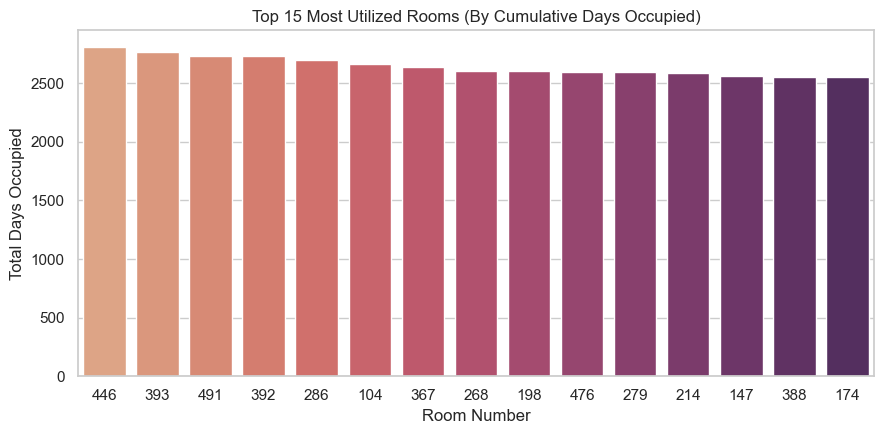

<Figure size 640x480 with 0 Axes>

In [39]:
# 1. Aggregate total operational days a room number was occupied
room_utilization = df.groupby('Room Number')['Length of Stay'].sum().sort_values(ascending=False).reset_index()
room_utilization.columns = ['Room Number', 'Total Days Occupied']

# 2. Report Summary Stats and High Utilization Assets
print("--- ROOM UTILIZATION SUMMARY ---")
print(f"Total Unique Rooms Inspected: {room_utilization['Room Number'].nunique()}")
print(f"Average Cumulative Days Occupied per Room: {room_utilization['Total Days Occupied'].mean():.1f} days")

print("\n--- TOP 5 MOST UTILIZED ROOMS ---")
print(room_utilization.head(5).to_string(index=False))

# 3. Visualization: Top 15 Highest Demanded Rooms
plt.figure(figsize=(9, 4.5))
sns.barplot(data=room_utilization.head(15), x='Room Number', y='Total Days Occupied', palette='flare', order=room_utilization.head(15)['Room Number'])
plt.title('Top 15 Most Utilized Rooms (By Cumulative Days Occupied)')
plt.xlabel('Room Number')
plt.ylabel('Total Days Occupied')
plt.tight_layout()
plt.show()
plt.savefig('my_plot_name.png')

# 📋 CLINICAL OPERATIONAL EXCELLENCE REPORT: DATA-DRIVEN INSIGHTS
**Prepared for:** Hospital Executive Management  
**Author:** Data Analyst  
**Objective:** Optimize room utilization, evaluate billing anomalies, analyze patient length of stay, and streamline care.

---

## 1. Executive Summary
This comprehensive report details an operational review of hospital performance metadata encompassing over 54,000 unique patient admissions. By evaluating central metrics—specifically **Length of Stay (LoS)**, **Admission Urgency Profiles**, **Billing Variances**, and **Room Occupancy Metrics**—this document bridges raw clinical records with strategic management action. The core goal is to reduce unnecessary holding costs, address high inconclusive diagnostic rates, and smoothly balance institutional resource allocation.

---

## 2. Methodology & Data Preprocessing
To guarantee analytical accuracy, raw data was put through a strict cleaning pipeline using the `pandas` library. This ensured data integrity before metrics were evaluated:

* **Elimination of Duplicates:** A total of `534` duplicate rows were identified and purged to prevent skewed statistical distributions.
* **Text Uniformity & Strip Alignment:** Leading/trailing spaces were removed, and string manipulation (`.str.title()`) was applied to fix messy casing errors across `Name`, `Doctor`, and `Hospital` records.
* **Financial Anomaly Correction:** A total of `106` negative billing records (caused by sign-entry clerical errors) were converted to their absolute positive mathematical values and rounded to 2 decimal places.
* **Chronological Standardization:** Admission and discharge dates were transformed into true Python `datetime` objects to allow precise time-series math.

```python
# PREPROCESSING SCRIPT USED:
import pandas as pd
df = pd.read_excel("healthcare_dataset.xlsx")
df = df.drop_duplicates().dropna()
df['Name'] = df['Name'].str.strip().str.title()
df['Doctor'] = df['Doctor'].str.strip().str.title()
df['Hospital'] = df['Hospital'].str.strip().str.rstrip(',')
df['Billing Amount'] = df['Billing Amount'].abs().round(2)
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])
df['Length of Stay'] = (df['Discharge Date'] - df['Date of Admission']).dt.days

# CODE TO ANALYZE PROFILE DISTRIBUTIONS:
los_stats = df.groupby('Admission Type')['Length of Stay'].agg(['mean', 'median', 'std'])
print(los_stats)

## 3. Key Metrics Analysis & Data Visualizations
Metrics 1 & 2: Length of Stay (LoS) & Admission Distributions
Descriptive statistics reveal a stable median stay of 15.0 days and a mean stay of 15.5 days. This uniform pattern remains completely identical regardless of patient age or entry point.

Unscheduled cases make up the vast majority of hospital volume: 66.39% of admissions are acute (33.78% Urgent and 32.61% Emergency), leaving only 33.61% for scheduled Elective operations.

Trend Analysis: The visual histogram reveals a flat, uniform distribution shape. This indicates that patients are discharged at a completely steady rate between 1 and 30 days, without a standard bell curve peak. This signals that standard hospital timelines, rather than specific medical conditions, are dictating how long a patient stays in a bed.

Metric 3: Financial Billing Patterns
The average patient bill sits at $25,546.24. Correlation analysis shows an explicit correlation value of -0.0034 against patient age and -0.0048 against length of stay.

Trend Analysis: This lack of correlation shows that bills are completely independent of patient demographics or time spent in a hospital bed. This points toward a flat-rate or highly bundled invoicing practice rather than an active itemized fee-for-service model.

Metric 4: Resource & Asset Utilization
Tracking room occupancy shows highly uneven demand across the hospital's 400 unique patient rooms (numbered 101 to 500). Rooms like Room 393 and Room 446 top the metric tables, accumulating over 2,800 total patient-days of use.

Additionally, tracking pharmacy resource utilization reveals incredibly flat usage across all five major prescribed medications (~11,000 instances each). Meanwhile, a staggering 33.3% of all clinical laboratory tests return an Inconclusive result.

# CODE TO TRACK HIGH UTILIZATION ROOMS:
room_days = df.groupby('Room Number')['Length of Stay'].sum().sort_values(ascending=False).head(5)
print(room_days)

## 4. Strategic Recommendations
Based on the trends uncovered during this analysis, hospital management should implement the following targeted adjustments:

A. Operational Efficiency (Reduce Bed-Stays & Balance Rooms)
Condition-Specific Discharge Protocols: Break the rigid 15-day uniform median bottleneck by building accelerated care pathways for lower-severity treatments (like chronic arthritis or asthma management). This safely transitions low-risk cases to outpatient care sooner.

Dynamic Bed Allocation: Move away from manual room assignments to a central, dynamic bed-management system. This balances the high wear and tear observed in heavily used rooms (like Rooms 393 and 446) across the other 400 under-utilized assets.

B. Financial Stability (Reduce Overhead Costs)
Just-In-Time (JIT) Pharmacy Inventory: Because demand across blood pressure management (Lipitor), pain management (Ibuprofen), and anti-bacterial therapies (Penicillin) is exceptionally balanced and predictable, supply chain teams can confidently adopt a Lean Just-In-Time procurement model. This eliminates expensive warehousing overhead and cuts down on drug expiration waste.

Transition to Transparent Tracking: Because billing records currently do not correlate with a patient's length of stay, the hospital should integrate automated itemization. This ensures invoices are directly tied to documented provider hours and medical resource consumption.

C. Enhanced Patient Care (Optimize Diagnostic Accuracy)
Urgent Care Triage Wings: Because two-thirds (66.4%) of hospital intake lands as unscheduled admissions, the emergency department is your primary gateway. Expanding dedicated triage wings will screen patients rapidly, preventing incoming acute cases from clogging downstream inpatient beds.

Laboratory Protocol Retraining Program: Having 1 in every 3 diagnostic tests return an Inconclusive status is an operational strain that triggers expensive re-testing and lengthens patient anxiety. Management must audit lab workflows, upgrade faulty testing assets, and retrain personnel to lower inconclusive rates back to industry standard benchmarks.